In [2]:
%matplotlib ipympl

In [7]:
# https://www.ercot.com/files/docs/2009/05/20/modelingguidelines_v06.pdf

In [3]:
import pandas as pd
from modo_energy_client.modo_energy_api_client import ModoEnergyAPIClient
from datetime import date
import numpy as np
from scipy.stats.mstats import winsorize
import statsmodels.formula.api as smf
from noaa.noaa_snowflake import get_noaa_weather_data
import matplotlib.pyplot as plt
from sklearn import preprocessing
from scipy.signal import periodogram

In [4]:
client = ModoEnergyAPIClient(cache_requests=True)

In [5]:
start = date(2024, 7, 1)
end = date(2026, 5, 31)

In [6]:
prices = client.get_ercot_prices(date_from=start, date_to=end)

Fetching pages : 0page [00:00, ?page/s]

In [7]:
hb_bus_avg_price = prices[prices["settlementPointName"] == "HB_HOUSTON"][
    "settlementPointPrice"
].astype(int)

In [8]:
hb_bus_avg_price_winsorized = pd.DataFrame(
    {hb_bus_avg_price.name: winsorize(hb_bus_avg_price, limits=[None, 0.01])},
    index=hb_bus_avg_price.index,
)

In [9]:
arbitrage_opprotunity = (
    hb_bus_avg_price_winsorized.resample("D")
    .agg(lambda d: d[d.index.hour == 19].item() - d[d.index.hour == 12].item())
    .rename(columns={"settlementPointPrice": "arbitrage_opportunity"})
).astype(int)


<Axes: xlabel='deliveryDate'>

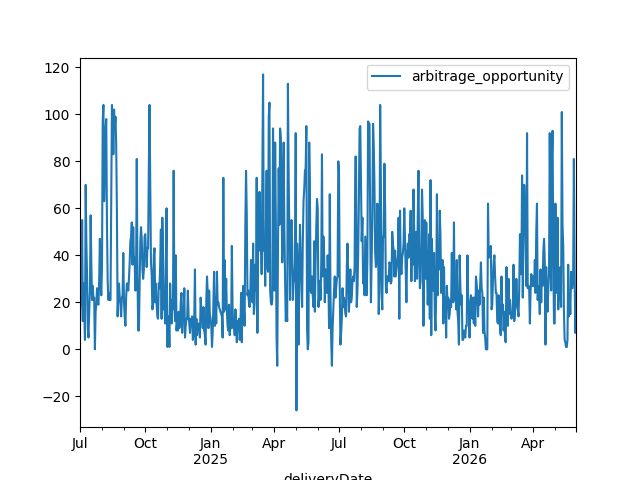

In [10]:
arbitrage_opprotunity.plot()

In [9]:
weather_data = get_noaa_weather_data()

In [27]:
min_max_scaler = preprocessing.MinMaxScaler()

In [34]:
time_span_weather_data = weather_data[weather_data.index > pd.to_datetime(start)]
wind_speed = time_span_weather_data[["Average daily wind speed"]]
wind_speed_normalized = pd.DataFrame(
    min_max_scaler.fit_transform(wind_speed),
    columns=wind_speed.columns,
    index=wind_speed.index,
)

In [35]:
arbitrage_opportunity_normalized = pd.DataFrame(
    min_max_scaler.fit_transform(arbitrage_opportunity),
    columns=arbitrage_opportunity.columns,
    index=arbitrage_opportunity.index,
)

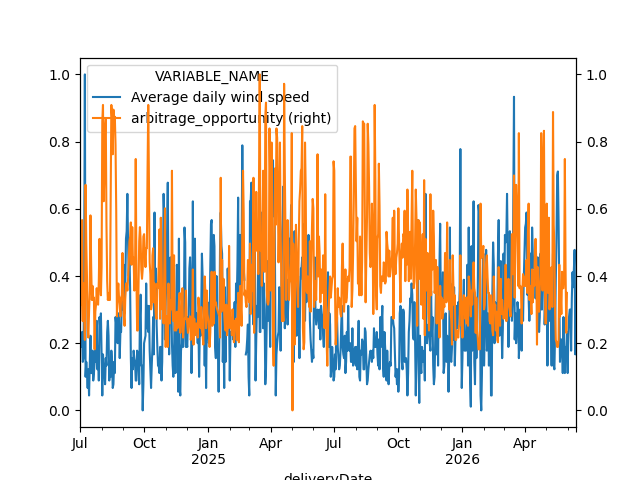

In [37]:
plt.clf()
wind_speed_plot = wind_speed_normalized.plot(
    legend=True, label="Average daily wind speed"
)
arbitrage_opportunity_normalized.plot(ax=wind_speed_plot, secondary_y=True)
plt.show()

In [43]:
X = wind_speed_normalized.join(arbitrage_opportunity_normalized)

In [39]:
X = pd.DataFrame(
    {
        "wind_speed": wind_speed_normalized,
        "arbitrage_opportunity": arbitrage_opportunity_normalized,
    },
    index=arbitrage_opportunity.index,
)

ValueError: Data must be 1-dimensional, got ndarray of shape (712, 1) instead

In [45]:
model = smf.ols("arbitrage_opportunity ~ wind_speed", data=X).fit()